### Plotting Nearest-Neighbor Distance (NND) Metrics

- Load nearest-neighbour distance (NND) data
- Apply a consistent lek ordering and labels
- Plot NND metrics against the lek ID

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import stan
from pathlib import Path

import nest_asyncio
nest_asyncio.apply()

import logging
logging.getLogger().setLevel(logging.ERROR)

/home/vivek/Documents/.pystan/lib/python3.12/site-packages/stan/plugins.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
## Output folder
out_dir = Path("output")
out_dir.mkdir(exist_ok=True)

In [3]:
## Load NND metrics
df = pd.read_csv('processed_data/nnd_ALL.csv')

## Factor ordering + labels
lek_order = ['TalChhapar_TC', 'Velavadar_LEK1', 'Velavadar_LEK2']
lek_labels = {'TalChhapar_TC': 'Tal Chhapar', 'Velavadar_LEK1': 'Velavadar Lek 1','Velavadar_LEK2': 'Velavadar Lek 2'}

df['lek_id'] = (pd.Categorical(df['lek_id'], categories=lek_order, ordered=True).rename_categories(lek_labels))

In [4]:
## Colour palettes
fill_cols = {'Tal Chhapar': '#B5542D', 'Velavadar Lek 1': '#1F6F8B', 'Velavadar Lek 2': '#3FA7A3'}
point_cols = {'Tal Chhapar': '#D97A52', 'Velavadar Lek 1': '#15556B', 'Velavadar Lek 2': '#2B7E7B'}

lek_labels = df['lek_id'].cat.categories.tolist()

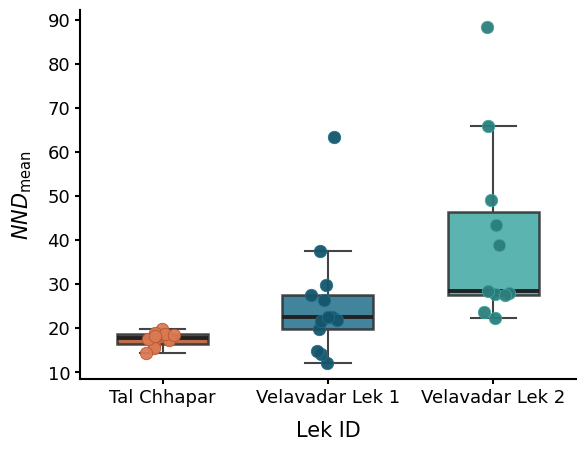

In [5]:
fig, ax = plt.subplots()

data_by_lek = [df.loc[df['lek_id'] == lek, 'nnd_mean'].values for lek in lek_labels]

bp = ax.boxplot(data_by_lek, positions=np.arange(len(lek_labels)), widths=0.55, patch_artist=True, 
                showfliers=False, boxprops=dict(color='#2B2B2B', linewidth=1.8),
                medianprops=dict(color='#222222', linewidth=2.8), whiskerprops=dict(linewidth=1.5, color='#444444'),
                capprops=dict(linewidth=1.5, color='#444444'))

for patch, lek in zip(bp['boxes'], lek_labels):
    patch.set_facecolor(fill_cols[lek])
    patch.set_alpha(0.85)

for i, lek in enumerate(lek_labels):
    y = df.loc[df['lek_id'] == lek, 'nnd_mean'].values
    x = np.random.normal(i, 0.06, size=len(y))
    ax.scatter(x, y, s=80, color=point_cols[lek], edgecolor=fill_cols[lek], linewidth=0.6, alpha=0.95, zorder=3)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

ax.tick_params(axis='both', which='major', labelsize=13, width=1.5)
ax.set_xticklabels(lek_labels)
ax.set_xlabel('Lek ID', fontsize=15, labelpad=10)
ax.set_ylabel(r'$NND_{\mathrm{mean}}$', fontsize=15, labelpad=10)

plt.savefig(out_dir/'nnd_mean.png', dpi=300, bbox_inches='tight')

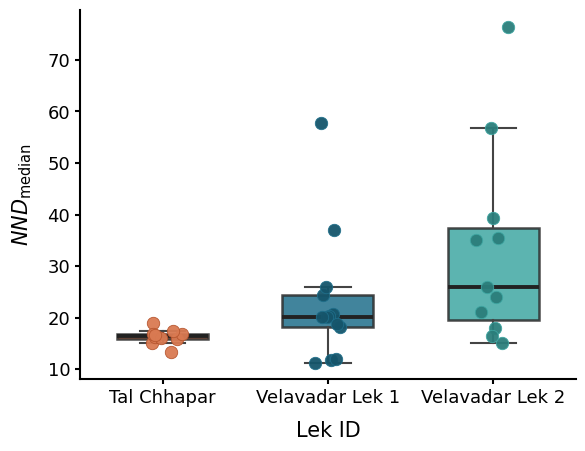

In [6]:
fig, ax = plt.subplots()

data_by_lek = [df.loc[df['lek_id'] == lek, 'nnd_median'].values for lek in lek_labels]

bp = ax.boxplot(data_by_lek, positions=np.arange(len(lek_labels)), widths=0.55, patch_artist=True, 
                showfliers=False, boxprops=dict(color='#2B2B2B', linewidth=1.8),
                medianprops=dict(color='#222222', linewidth=2.8), whiskerprops=dict(linewidth=1.5, color='#444444'),
                capprops=dict(linewidth=1.5, color='#444444'))

for patch, lek in zip(bp['boxes'], lek_labels):
    patch.set_facecolor(fill_cols[lek])
    patch.set_alpha(0.85)

for i, lek in enumerate(lek_labels):
    y = df.loc[df['lek_id'] == lek, 'nnd_median'].values
    x = np.random.normal(i, 0.06, size=len(y))
    ax.scatter(x, y, s=80, color=point_cols[lek], edgecolor=fill_cols[lek], linewidth=0.6, alpha=0.95, zorder=3)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

ax.tick_params(axis='both', which='major', labelsize=13, width=1.5)
ax.set_xticklabels(lek_labels)
ax.set_xlabel('Lek ID', fontsize=15, labelpad=10)
ax.set_ylabel(r'$NND_{\mathrm{median}}$', fontsize=15, labelpad=10)

plt.savefig(out_dir/'nnd_median.png', dpi=300, bbox_inches='tight')

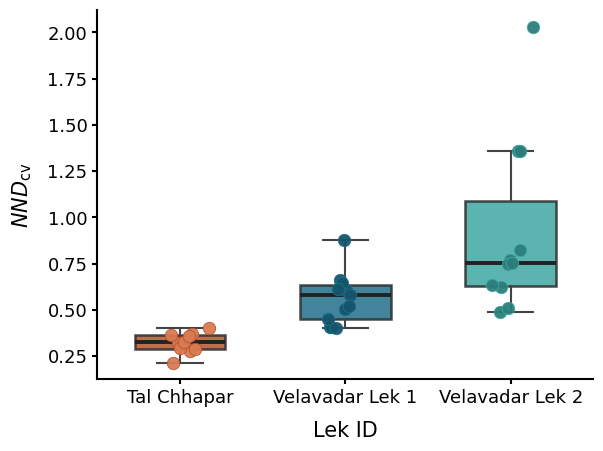

In [7]:
fig, ax = plt.subplots()

data_by_lek = [df.loc[df['lek_id'] == lek, 'nnd_cv'].values for lek in lek_labels]

bp = ax.boxplot(data_by_lek, positions=np.arange(len(lek_labels)), widths=0.55, patch_artist=True, 
                showfliers=False, boxprops=dict(color='#2B2B2B', linewidth=1.8),
                medianprops=dict(color='#222222', linewidth=2.8), whiskerprops=dict(linewidth=1.5, color='#444444'),
                capprops=dict(linewidth=1.5, color='#444444'))

for patch, lek in zip(bp['boxes'], lek_labels):
    patch.set_facecolor(fill_cols[lek])
    patch.set_alpha(0.85)

for i, lek in enumerate(lek_labels):
    y = df.loc[df['lek_id'] == lek, 'nnd_cv'].values
    x = np.random.normal(i, 0.06, size=len(y))
    ax.scatter(x, y, s=80, color=point_cols[lek], edgecolor=fill_cols[lek], linewidth=0.6, alpha=0.95, zorder=3)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

ax.tick_params(axis='both', which='major', labelsize=13, width=1.5)
ax.set_xticklabels(lek_labels)
ax.set_xlabel('Lek ID', fontsize=15, labelpad=10)
ax.set_ylabel(r'$NND_{\mathrm{cv}}$', fontsize=15, labelpad=10)

plt.savefig(out_dir/'nnd_cv.png', dpi=300, bbox_inches='tight')

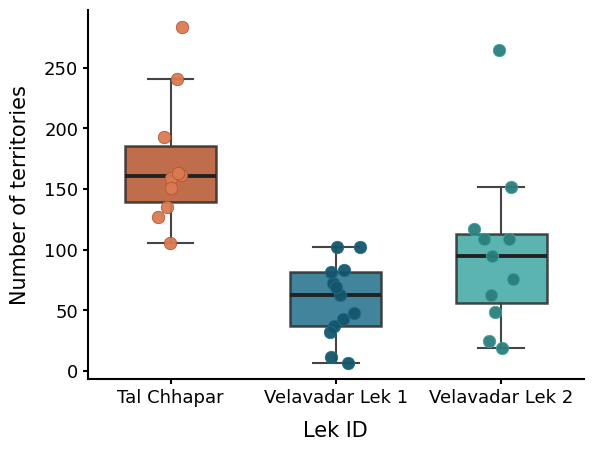

In [8]:
fig, ax = plt.subplots()

data_by_lek = [df.loc[df['lek_id'] == lek, 'nnd_count'].values for lek in lek_labels]

bp = ax.boxplot(data_by_lek, positions=np.arange(len(lek_labels)), widths=0.55, patch_artist=True, 
                showfliers=False, boxprops=dict(color='#2B2B2B', linewidth=1.8),
                medianprops=dict(color='#222222', linewidth=2.8), whiskerprops=dict(linewidth=1.5, color='#444444'),
                capprops=dict(linewidth=1.5, color='#444444'))

for patch, lek in zip(bp['boxes'], lek_labels):
    patch.set_facecolor(fill_cols[lek])
    patch.set_alpha(0.85)

for i, lek in enumerate(lek_labels):
    y = df.loc[df['lek_id'] == lek, 'nnd_count'].values
    x = np.random.normal(i, 0.06, size=len(y))
    ax.scatter(x, y, s=80, color=point_cols[lek], edgecolor=fill_cols[lek], linewidth=0.6, alpha=0.95, zorder=3)



ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

ax.tick_params(axis='both', which='major', labelsize=13, width=1.5)
ax.set_xticklabels(lek_labels)
ax.set_xlabel('Lek ID', fontsize=15, labelpad=10)
ax.set_ylabel('Number of territories', fontsize=15, labelpad=10)


plt.savefig(out_dir/'territory_count.png', dpi=300, bbox_inches='tight')

In [9]:
df['date'] = pd.to_datetime(df['date'])

df = df[['lek_id', 'date', 'nnd_median', 'nnd_cv', 'nnd_count']].dropna().copy()
df = df.sort_values(['lek_id', 'date']).reset_index(drop=True)

## Serialise and centre the date / time
t0 = df['date'].min()
df['t_years'] = (df['date'] - t0).dt.days / 365.25
df['t_centred'] = df['t_years'] - df['t_years'].mean()

## Log transform nnd columns to construct a log-normal model
df['log_nnd_median'] = np.log(df['nnd_median'].astype(float))
df['log_nnd_cv'] = np.log(df['nnd_cv'].astype(float))
df['log_nnd_count'] = np.log(df['nnd_count'].astype(float))

## Encode lek ID in a numerical variable
lek_levels = sorted(df['lek_id'].unique())
lek_map = {lek: i + 1 for i, lek in enumerate(lek_levels)}
df['site_id'] = df['lek_id'].map(lek_map).astype(int)

In [10]:
## Model the change in median of the NND to show that local repulsion interactions remain conserved
local_repulsion_mod = """
data {
  int<lower=1> n_points;
  int<lower=1> n_sites;
  
  array[n_points] int<lower=1,upper=n_sites> site_id;
  
  vector[n_points] t;
  vector[n_points] n_territories;
  vector[n_points] y;
}

parameters {
  real mu_alpha;
  real mu_beta;
  real gamma;

  vector[n_sites] alpha_raw;
  vector[n_sites] beta_raw;

  real<lower=0> tau_alpha;
  real<lower=0> tau_beta;

  real<lower=0> sigma;
}

transformed parameters {
  vector[n_sites] alpha = mu_alpha + tau_alpha * alpha_raw;
  vector[n_sites] beta  = mu_beta + tau_beta  * beta_raw;
}

model {
  mu_alpha ~ normal(0, 1);
  mu_beta ~ normal(0, 0.5);
  gamma ~ normal(0, 0.5);

  alpha_raw ~ normal(0, 1);
  beta_raw ~ normal(0, 1);

  tau_alpha ~ exponential(1);
  tau_beta ~ exponential(1);
  sigma ~ exponential(1);

  for (n in 1:n_points) {
    y[n] ~ normal(alpha[site_id[n]] + beta[site_id[n]] * t[n] + gamma * n_territories[n], sigma);
  }
}

generated quantities {
  vector[n_points] y_hat;
  for (n in 1:n_points) {
    y_hat[n] = normal_rng(alpha[site_id[n]] + beta[site_id[n]] * t[n] + gamma * n_territories[n], sigma);
  }
}
"""

In [11]:
data_repulsion = {
    'n_points': len(df),
    'n_sites': int(df['site_id'].nunique()),
    'site_id': df['site_id'].astype(int).to_numpy(),
    't': df['t_centred'].astype(float).to_numpy(),
    'n_territories': df['log_nnd_count'].astype(float).to_numpy(),
    'y': df['log_nnd_median'].astype(float).to_numpy()
}

posterior = stan.build(local_repulsion_mod, data=data_repulsion)
fit = posterior.sample(num_chains=4, num_warmup=1000, num_samples=1000)

Building: found in cache, done.
Sampling:   0%
Sampling:   0% (1/8000)
Sampling:   1% (101/8000)
Sampling:   3% (201/8000)
Sampling:   4% (301/8000)
Sampling:   8% (600/8000)
Sampling:  10% (800/8000)
Sampling:  14% (1100/8000)
Sampling:  18% (1400/8000)
Sampling:  22% (1800/8000)
Sampling:  28% (2200/8000)
Sampling:  31% (2500/8000)
Sampling:  34% (2700/8000)
Sampling:  50% (4000/8000)
Sampling:  66% (5300/8000)
Sampling:  82% (6600/8000)
Sampling: 100% (8000/8000)
Sampling: 100% (8000/8000), done.
Messages received during sampling:
  Gradient evaluation took 4.2e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.42 seconds.
  Adjust your expectations accordingly!
  Gradient evaluation took 4.6e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.46 seconds.
  Adjust your expectations accordingly!
  Gradient evaluation took 4.6e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.46 seconds.
  

In [12]:
## Fix the number of territories for each lek to median to plot the effect of time on NND
fix_logN = df.groupby('lek_id')['log_nnd_count'].median().to_dict()

## Specify time axis
t_min, t_max = float(df['t_centred'].min()), float(df['t_centred'].max())
t_grid = np.linspace(t_min, t_max, 200)
t_years = t_grid + df['t_years'].mean()
date_grid = t0 + pd.to_timedelta(t_years * 365.25, unit='D')

/tmp/ipykernel_129412/761641419.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fix_logN = df.groupby('lek_id')['log_nnd_count'].median().to_dict()


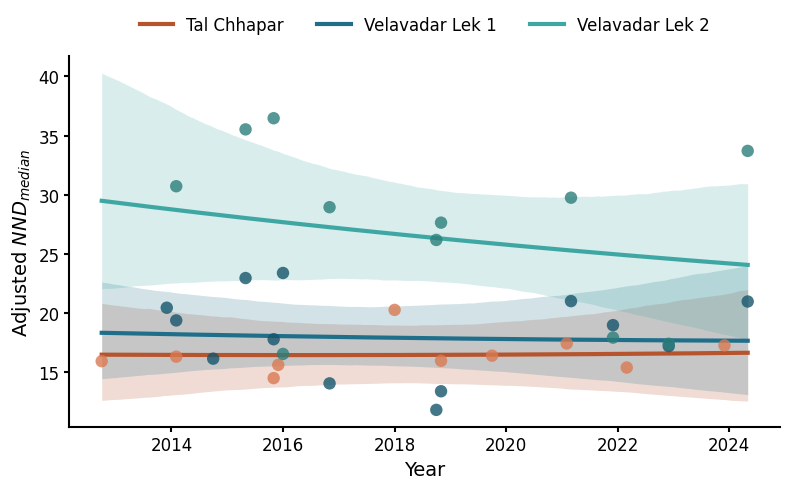

In [13]:
## Plot the change in NND with time while controlling for the number of territories
fig, ax = plt.subplots(figsize=(8, 5))

for lek in lek_labels:
    df_lek = df[df['lek_id'] == lek].copy()
    site_id = np.unique(df_lek['site_id'] - 1)[0]
    logN0 = fix_logN[lek]

    # Compute posterior mean log(NND_median) and back-transform to return to original units 
    mu = fit['alpha'][site_id,:].reshape(-1,1) + fit['beta'][site_id,:].reshape(-1,1) * t_grid[None,:] + fit['gamma'].reshape(-1,1) * logN0
    y = np.exp(mu)
    y_mean = np.mean(y, axis=0)
    y_lower,y_upper = np.quantile(y, [0.025,0.975], axis=0)

    # Plot model fits
    ax.plot(date_grid, y_mean, linewidth=3, color=fill_cols.get(lek), label=str(lek))
    ax.fill_between(date_grid, y_lower, y_upper, color=fill_cols.get(lek), alpha=0.2, linewidth=0)

    # Add scatter to the plot (logNND_adjusted = logNND_observed + gamma * (logN_0 - logN_obs))
    df_lek['nnd_median_adj'] = np.exp(df_lek['log_nnd_median'] + fit['gamma'].mean() * (logN0 - df['log_nnd_count']))
    ax.scatter(df_lek['date'], df_lek['nnd_median_adj'], s=80, color=point_cols.get(lek), edgecolor='none', alpha=0.8, zorder=4)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.tick_params(axis='both', which='major', labelsize=12, width=1.5)

    ax.set_xlabel('Year', fontsize=14)
    ax.set_ylabel('Adjusted $NND_{median}$', fontsize=14)

    ax.legend(frameon=False, fontsize=12, ncol=3, loc='upper center', bbox_to_anchor=(0.5, 1.15))
    plt.tight_layout()
    plt.savefig(out_dir/'adjusted_nnd_median.png', dpi=300, bbox_inches='tight')

In [14]:
## Specify n_territories axis
N_min, N_max = int(df['nnd_count'].min()), int(df['nnd_count'].max())
N_grid = np.linspace(N_min, N_max, 200)
logN_grid = np.log(N_grid)

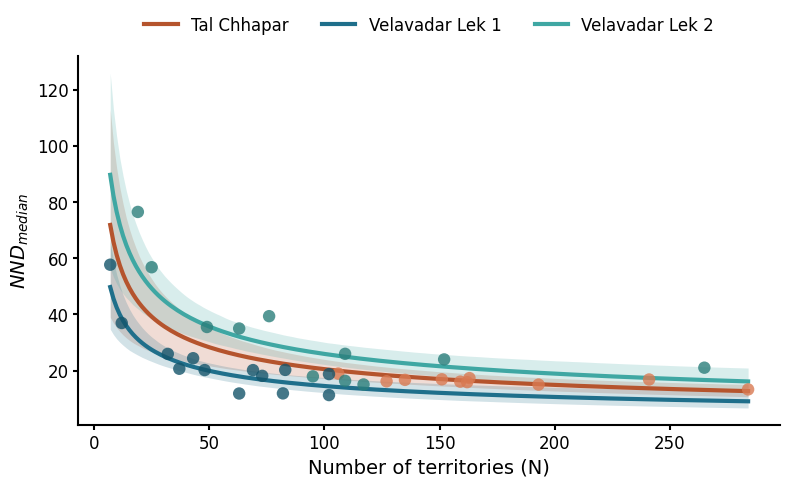

In [15]:
## Plot change in number of territories with time while controlling for NND 
fig, ax = plt.subplots(figsize=(8, 5))

for lek in lek_labels:
    df_lek = df[df['lek_id'] == lek].copy()
    site_id = np.unique(df_lek['site_id'] - 1)[0]

    # Compute posterior mean log(NND_median) and back-transform to return to original units 
    mu = fit['alpha'][site_id, :].reshape(-1, 1) + fit['gamma'].reshape(-1, 1) * logN_grid.reshape(1, -1)
    y = np.exp(mu)
    y_mean = np.mean(y, axis=0)
    y_lower,y_upper = np.quantile(y, [0.025,0.975], axis=0)

    # Plot model fits
    ax.plot(N_grid, y_mean, linewidth=3, color=fill_cols.get(lek), label=str(lek))
    ax.fill_between(N_grid, y_lower, y_upper, color=fill_cols.get(lek), alpha=0.2, linewidth=0)

    # Overlay observed points (raw relationship, not adjusted)
    ax.scatter(df_lek['nnd_count'], df_lek['nnd_median'], s=80, color=point_cols.get(lek), edgecolor='none', alpha=0.8, zorder=4)

# Cosmetics
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.tick_params(axis='both', which='major', labelsize=12, width=1.5)

ax.set_xlabel('Number of territories (N)', fontsize=14)
ax.set_ylabel('$NND_{median}$', fontsize=14)

ax.legend(frameon=False, fontsize=12, ncol=3, loc='upper center', bbox_to_anchor=(0.5, 1.15))
plt.tight_layout()
plt.show()

In [16]:
## Model the change in CV of the NND to show that local repulsion interactions remain conserved
local_repulsion_mod = """
data {
  int<lower=1> n_points;
  int<lower=1> n_sites;
  
  array[n_points] int<lower=1,upper=n_sites> site_id;
  
  vector[n_points] t;
  vector[n_points] n_territories;
  vector[n_points] y;
}

parameters {
  real mu_alpha;
  real mu_beta;
  real gamma;

  vector[n_sites] alpha_raw;
  vector[n_sites] beta_raw;

  real<lower=0> tau_alpha;
  real<lower=0> tau_beta;

  real<lower=0> sigma;
}

transformed parameters {
  vector[n_sites] alpha = mu_alpha + tau_alpha * alpha_raw;
  vector[n_sites] beta  = mu_beta + tau_beta  * beta_raw;
}

model {
  mu_alpha ~ normal(0, 1);
  mu_beta ~ normal(0, 0.5);
  gamma ~ normal(0, 0.5);

  alpha_raw ~ normal(0, 1);
  beta_raw ~ normal(0, 1);

  tau_alpha ~ exponential(1);
  tau_beta ~ exponential(1);
  sigma ~ exponential(1);

  for (n in 1:n_points) {
    y[n] ~ normal(alpha[site_id[n]] + beta[site_id[n]] * t[n] + gamma * n_territories[n], sigma);
  }
}

generated quantities {
  vector[n_points] y_hat;
  for (n in 1:n_points) {
    y_hat[n] = normal_rng(alpha[site_id[n]] + beta[site_id[n]] * t[n] + gamma * n_territories[n], sigma);
  }
}
"""

In [17]:
data_repulsion = {
    'n_points': len(df),
    'n_sites': int(df['site_id'].nunique()),
    'site_id': df['site_id'].astype(int).to_numpy(),
    't': df['t_centred'].astype(float).to_numpy(),
    'n_territories': df['log_nnd_count'].astype(float).to_numpy(),
    'y': df['log_nnd_cv'].astype(float).to_numpy()
}

posterior = stan.build(local_repulsion_mod, data=data_repulsion)
fit = posterior.sample(num_chains=4, num_warmup=1000, num_samples=1000)

Building: found in cache, done.
Sampling:   0%
Sampling:   2% (200/8000)
Sampling:   8% (600/8000)
Sampling:  14% (1100/8000)
Sampling:  39% (3100/8000)
Sampling:  61% (4900/8000)
Sampling:  81% (6500/8000)
Sampling: 100% (8000/8000)
Sampling: 100% (8000/8000), done.
Messages received during sampling:
  Gradient evaluation took 4.4e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.44 seconds.
  Adjust your expectations accordingly!
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/tmp/httpstan_p23zacsv/model_5c5myffb.stan', line 45, column 4 to column 97)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or misspecified.
  Gradient evaluation 

In [18]:
## Fix the number of territories for each lek to median to plot the effect of time on NND
fix_logN = df.groupby('lek_id')['log_nnd_count'].median().to_dict()

## Specify time axis
t_min, t_max = float(df['t_centred'].min()), float(df['t_centred'].max())
t_grid = np.linspace(t_min, t_max, 200)
t_years = t_grid + df['t_years'].mean()
date_grid = t0 + pd.to_timedelta(t_years * 365.25, unit='D')

/tmp/ipykernel_129412/761641419.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fix_logN = df.groupby('lek_id')['log_nnd_count'].median().to_dict()


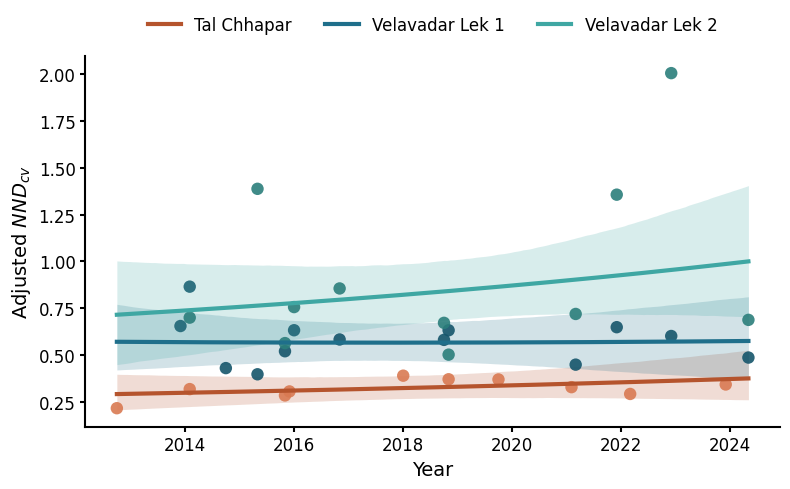

In [19]:
## Plot the change in NND with time while controlling for the number of territories
fig, ax = plt.subplots(figsize=(8, 5))

for lek in lek_labels:
    df_lek = df[df['lek_id'] == lek].copy()
    site_id = np.unique(df_lek['site_id'] - 1)[0]
    logN0 = fix_logN[lek]

    # Compute posterior mean log(NND_median) and back-transform to return to original units 
    mu = fit['alpha'][site_id,:].reshape(-1,1) + fit['beta'][site_id,:].reshape(-1,1) * t_grid[None,:] + fit['gamma'].reshape(-1,1) * logN0
    y = np.exp(mu)
    y_mean = np.mean(y, axis=0)
    y_lower,y_upper = np.quantile(y, [0.025,0.975], axis=0)

    # Plot model fits
    ax.plot(date_grid, y_mean, linewidth=3, color=fill_cols.get(lek), label=str(lek))
    ax.fill_between(date_grid, y_lower, y_upper, color=fill_cols.get(lek), alpha=0.2, linewidth=0)

    # Add scatter to the plot (logNND_adjusted = logNND_observed + gamma * (logN_0 - logN_obs))
    df_lek['nnd_cv_adj'] = np.exp(df_lek['log_nnd_cv'] + fit['gamma'].mean() * (logN0 - df['log_nnd_count']))
    ax.scatter(df_lek['date'], df_lek['nnd_cv_adj'], s=80, color=point_cols.get(lek), edgecolor='none', alpha=0.9, zorder=1)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.tick_params(axis='both', which='major', labelsize=12, width=1.5)

    ax.set_xlabel('Year', fontsize=14)
    ax.set_ylabel('Adjusted $NND_{cv}$', fontsize=14)

    ax.legend(frameon=False, fontsize=12, ncol=3, loc='upper center', bbox_to_anchor=(0.5, 1.15))
    plt.tight_layout()
    plt.savefig(out_dir/'adjusted_nnd_cv.png', dpi=300, bbox_inches='tight')

In [20]:
## Specify n_territories axis
N_min, N_max = int(df['nnd_count'].min()), int(df['nnd_count'].max())
N_grid = np.linspace(N_min, N_max, 200)
logN_grid = np.log(N_grid)

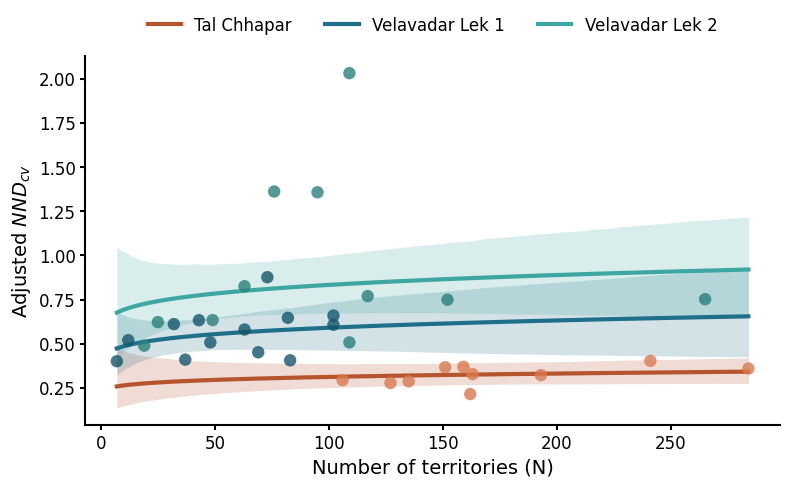

In [25]:
## Plot change in number of territories with time while controlling for NND 
fig, ax = plt.subplots(figsize=(8, 5))

for lek in lek_labels:
    df_lek = df[df['lek_id'] == lek].copy()
    site_id = np.unique(df_lek['site_id'] - 1)[0]

    # Compute posterior mean log(NND_median) and back-transform to return to original units 
    mu = fit['alpha'][site_id, :].reshape(-1, 1) + fit['gamma'].reshape(-1, 1) * logN_grid.reshape(1, -1)
    y = np.exp(mu)
    y_mean = np.mean(y, axis=0)
    y_lower,y_upper = np.quantile(y, [0.025,0.975], axis=0)

    # Plot model fits
    ax.plot(N_grid, y_mean, linewidth=3, color=fill_cols.get(lek), label=str(lek))
    ax.fill_between(N_grid, y_lower, y_upper, color=fill_cols.get(lek), alpha=0.2, linewidth=0)

    # Overlay observed points (raw relationship, not adjusted)
    ax.scatter(df_lek['nnd_count'], df_lek['nnd_cv'], s=80, color=point_cols.get(lek), edgecolor='none', alpha=0.8, zorder=4)

# Cosmetics
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.tick_params(axis='both', which='major', labelsize=12, width=1.5)

ax.set_xlabel('Number of territories (N)', fontsize=14)
ax.set_ylabel('Adjusted $NND_{cv}$', fontsize=14)

ax.legend(frameon=False, fontsize=12, ncol=3, loc='upper center', bbox_to_anchor=(0.5, 1.15))
plt.tight_layout()
plt.show()